In [ ]:
import umap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from collections import Counter
from sentence_transformers import SentenceTransformer

## All VLMs combined

In [94]:
data = pd.read_pickle('/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_activity/allVLM_activity_vocab_deduplication_results.pkl')
deduped_vocabs,global_duplicates,canonical_map,labels = data['deduped_vocabularies'], data['global_duplicates'], data['canonical_map'], data['labels']

In [95]:
deduped_vocabs[-2], deduped_vocabs[-1] = deduped_vocabs[-1], deduped_vocabs[-2] # swap the last two regions
labels[-2], labels[-1] = labels[-1], labels[-2] # swap the last two regions

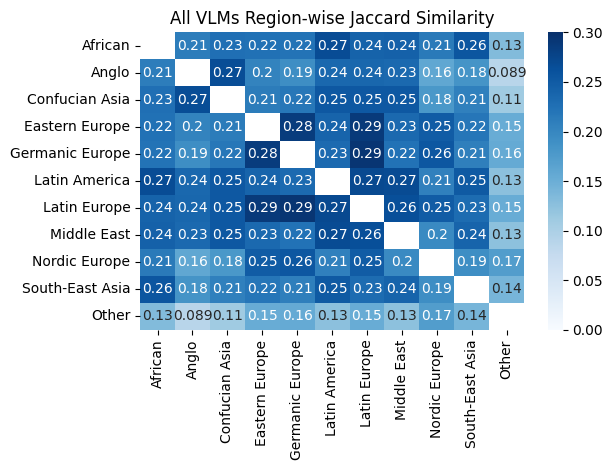

In [96]:
# compute region-wise jaccard similarity of the deduped_vocabs and visualize it as a heatmap using seaborn
regions = labels
all_jaccard_matrix = pd.DataFrame(index=regions, columns=regions, dtype=float)
for i in range(len(regions)):
    for j in range(len(regions)):
        if i != j:
            set_i = set(deduped_vocabs[i])
            set_j = set(deduped_vocabs[j])
            intersection = len(set_i.intersection(set_j))
            union = len(set_i.union(set_j))
            jaccard_similarity = intersection / union if union > 0 else 0
            all_jaccard_matrix.iloc[i, j] = jaccard_similarity

sns.heatmap(all_jaccard_matrix, annot=True, cmap="Blues", vmin=0, vmax=0.3)
plt.title("All VLMs Region-wise Jaccard Similarity")
plt.tight_layout()
plt.savefig('outputs/jaccard/all_vlm_region_jaccard_similarity.png')

## Individual VLM

In [97]:
data = pd.read_pickle('/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_activity/indVLM_activity_vocab_deduplication_results.pkl')
deduped_vocabs,global_duplicates,canonical_map,labels = data['deduped_vocabularies'], data['global_duplicates'], data['canonical_map'], data['labels']

NUM_REGIONS = 11

dpsk_vocab = {l.split("_")[0]:v for l,v in zip(labels[:NUM_REGIONS], deduped_vocabs[:NUM_REGIONS])}
llva_vocab = {l.split("_")[0]:v for l,v in zip(labels[NUM_REGIONS:2*NUM_REGIONS], deduped_vocabs[NUM_REGIONS:2*NUM_REGIONS])}
qw7b_vocab = {l.split("_")[0]:v for l,v in zip(labels[2*NUM_REGIONS:3*NUM_REGIONS], deduped_vocabs[2*NUM_REGIONS:3*NUM_REGIONS])}
qw72b_vocab = {l.split("_")[0]:v for l,v in zip(labels[3*NUM_REGIONS:4*NUM_REGIONS], deduped_vocabs[3*NUM_REGIONS:4*NUM_REGIONS])}
qw30b_vocab = {l.split("_")[0]:v for l,v in zip(labels[4*NUM_REGIONS:], deduped_vocabs[4*NUM_REGIONS:])}

### deepseek

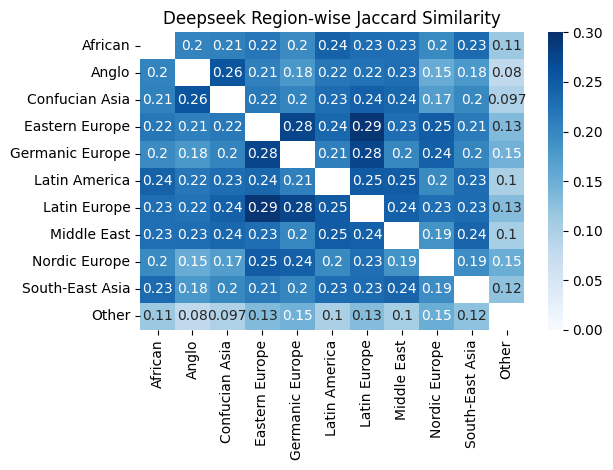

In [98]:
# for dpsk_vocab, compute region-wise jaccard similarity of the deduped_vocabs and visualize it as a heatmap using seaborn

regions = list(dpsk_vocab.keys())
regions[-2], regions[-1] = regions[-1], regions[-2] # swap the last two regions
dpsk_jaccard_matrix = pd.DataFrame(index=regions, columns=regions, dtype=float)
for i in range(len(regions)):
    for j in range(len(regions)):
        if i != j:
            set_i = set(dpsk_vocab[regions[i]])
            set_j = set(dpsk_vocab[regions[j]])
            intersection = len(set_i.intersection(set_j))
            union = len(set_i.union(set_j))
            jaccard_similarity = intersection / union if union > 0 else 0
            dpsk_jaccard_matrix.iloc[i, j] = jaccard_similarity
sns.heatmap(dpsk_jaccard_matrix, annot=True, cmap="Blues", vmin=0, vmax=0.3)
plt.title("Deepseek Region-wise Jaccard Similarity")
plt.tight_layout()
plt.savefig('outputs/jaccard/dpsk_region_jaccard_similarity.png')

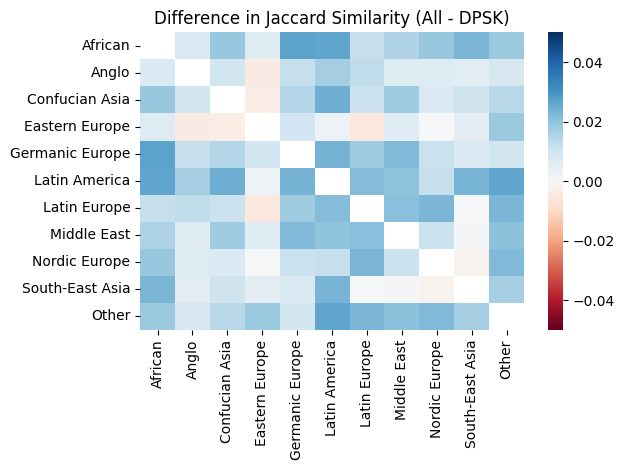

In [99]:
# compute difference with all_jaccard_matrix and visualize it as a heatmap
difference_matrix = all_jaccard_matrix - dpsk_jaccard_matrix
sns.heatmap(difference_matrix, annot=False, cmap="RdBu", center=0, vmin=-0.05, vmax=0.05)
plt.title("Difference in Jaccard Similarity (All - DPSK)")
plt.tight_layout()
plt.savefig('outputs/jaccard/dpsk_difference_jaccard_similarity.png')

### llava

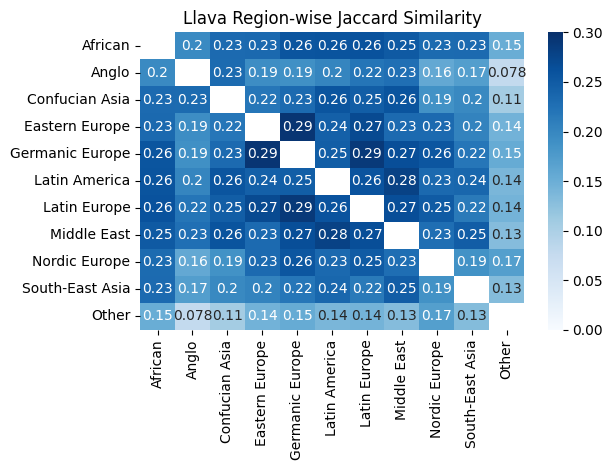

In [100]:
# for llva_vocab, compute region-wise jaccard similarity of the deduped_vocabs and visualize it as a heatmap using seaborn

regions = list(llva_vocab.keys())
regions[-2], regions[-1] = regions[-1], regions[-2] # swap the last two regions
llva_jaccard_matrix = pd.DataFrame(index=regions, columns=regions, dtype=float)
for i in range(len(regions)):
    for j in range(len(regions)):
        if i != j:
            set_i = set(llva_vocab[regions[i]])
            set_j = set(llva_vocab[regions[j]])
            intersection = len(set_i.intersection(set_j))
            union = len(set_i.union(set_j))
            jaccard_similarity = intersection / union if union > 0 else 0
            llva_jaccard_matrix.iloc[i, j] = jaccard_similarity
sns.heatmap(llva_jaccard_matrix, annot=True, cmap="Blues", vmin=0, vmax=0.3)
plt.title("Llava Region-wise Jaccard Similarity")
plt.tight_layout()
plt.savefig('outputs/jaccard/llva_region_jaccard_similarity.png')

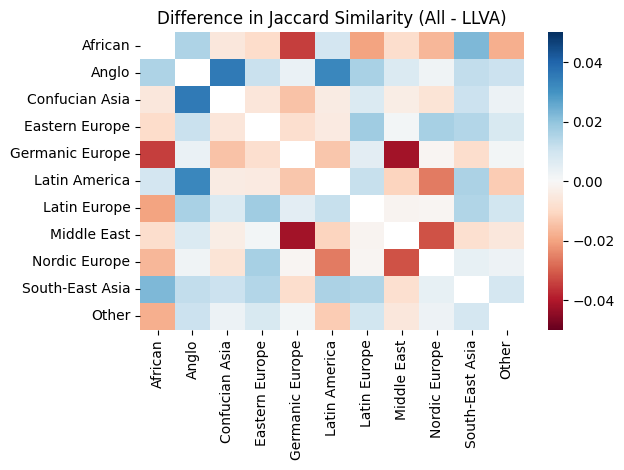

In [101]:
difference_matrix = all_jaccard_matrix - llva_jaccard_matrix
sns.heatmap(difference_matrix, annot=False, cmap="RdBu", center=0, vmin=-0.05, vmax=0.05)
plt.title("Difference in Jaccard Similarity (All - LLVA)")
plt.tight_layout()
plt.savefig('outputs/jaccard/llva_difference_jaccard_similarity.png')

### qwen 7b

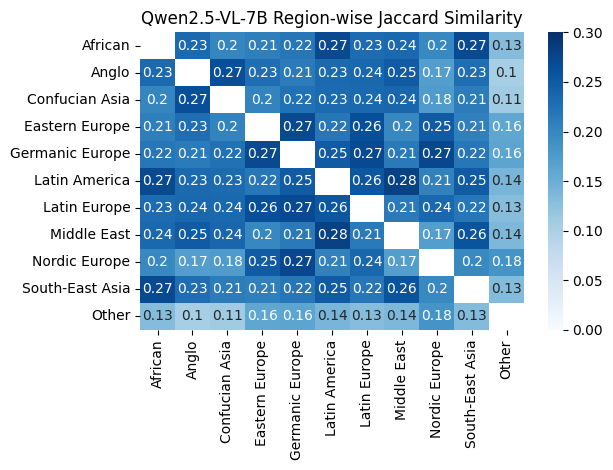

In [102]:
# for qw7b_vocab, compute region-wise jaccard similarity of the deduped_vocabs and visualize it as a heatmap using seaborn

regions = list(qw7b_vocab.keys())
regions[-2], regions[-1] = regions[-1], regions[-2] # swap the last two regions
qw7b_jaccard_matrix = pd.DataFrame(index=regions, columns=regions, dtype=float)
for i in range(len(regions)):
    for j in range(len(regions)):
        if i != j:
            set_i = set(qw7b_vocab[regions[i]])
            set_j = set(qw7b_vocab[regions[j]])
            intersection = len(set_i.intersection(set_j))
            union = len(set_i.union(set_j))
            jaccard_similarity = intersection / union if union > 0 else 0
            qw7b_jaccard_matrix.iloc[i, j] = jaccard_similarity
sns.heatmap(qw7b_jaccard_matrix, annot=True, cmap="Blues", vmin=0, vmax=0.3)
plt.title("Qwen2.5-VL-7B Region-wise Jaccard Similarity")
plt.tight_layout()
plt.savefig('outputs/jaccard/qw7b_region_jaccard_similarity.png')

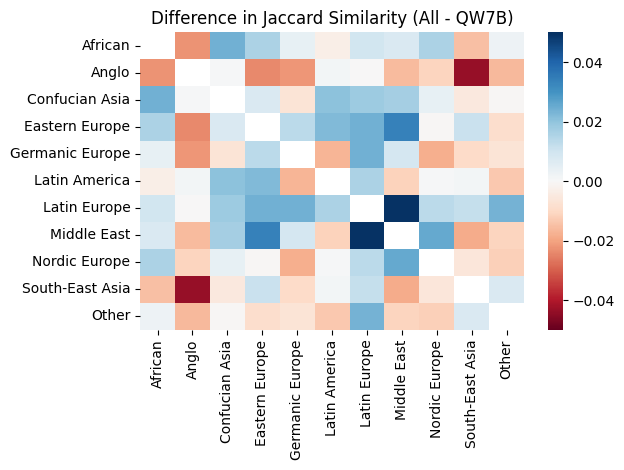

In [103]:
difference_matrix = all_jaccard_matrix - qw7b_jaccard_matrix
sns.heatmap(difference_matrix, annot=False, cmap="RdBu", center=0, vmin=-0.05, vmax=0.05)
plt.title("Difference in Jaccard Similarity (All - QW7B)")
plt.tight_layout()
plt.savefig('outputs/jaccard/qw7b_difference_jaccard_similarity.png')

### qwen 72b

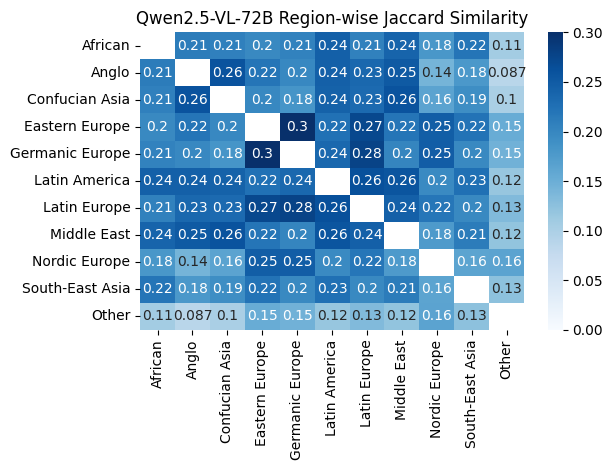

In [104]:
# for qw72b_vocab, compute region-wise jaccard similarity of the deduped_vocabs and visualize it as a heatmap using seaborn

regions = list(qw72b_vocab.keys())
regions[-2], regions[-1] = regions[-1], regions[-2] # swap the last two regions
qw72b_jaccard_matrix = pd.DataFrame(index=regions, columns=regions, dtype=float)
for i in range(len(regions)):
    for j in range(len(regions)):
        if i != j:
            set_i = set(qw72b_vocab[regions[i]])
            set_j = set(qw72b_vocab[regions[j]])
            intersection = len(set_i.intersection(set_j))
            union = len(set_i.union(set_j))
            jaccard_similarity = intersection / union if union > 0 else 0
            qw72b_jaccard_matrix.iloc[i, j] = jaccard_similarity
sns.heatmap(qw72b_jaccard_matrix, annot=True, cmap="Blues", vmin=0, vmax=0.3)
plt.title("Qwen2.5-VL-72B Region-wise Jaccard Similarity")
plt.tight_layout()
plt.savefig('outputs/jaccard/qw72b_region_jaccard_similarity.png')

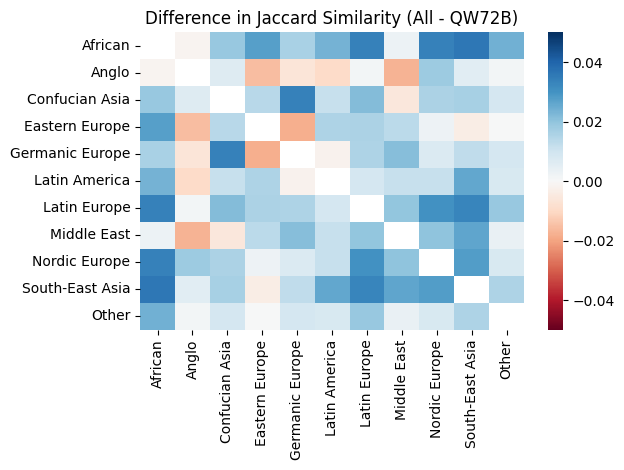

In [105]:
difference_matrix = all_jaccard_matrix - qw72b_jaccard_matrix
sns.heatmap(difference_matrix, annot=False, cmap="RdBu", center=0, vmin=-0.05, vmax=0.05)
plt.title("Difference in Jaccard Similarity (All - QW72B)")
plt.tight_layout()
plt.savefig('outputs/jaccard/qw72b_difference_jaccard_similarity.png')

### qwen 30b

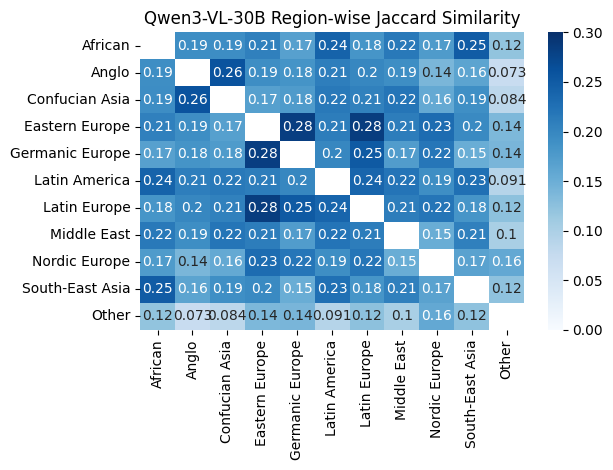

In [106]:
# for qw30b_vocab, compute region-wise jaccard similarity of the deduped_vocabs and visualize it as a heatmap using seaborn

regions = list(qw30b_vocab.keys())
regions[-2], regions[-1] = regions[-1], regions[-2] # swap the last two regions
qw30b_jaccard_matrix = pd.DataFrame(index=regions, columns=regions, dtype=float)
for i in range(len(regions)):
    for j in range(len(regions)):
        if i != j:
            set_i = set(qw30b_vocab[regions[i]])
            set_j = set(qw30b_vocab[regions[j]])
            intersection = len(set_i.intersection(set_j))
            union = len(set_i.union(set_j))
            jaccard_similarity = intersection / union if union > 0 else 0
            qw30b_jaccard_matrix.iloc[i, j] = jaccard_similarity
sns.heatmap(qw30b_jaccard_matrix, annot=True, cmap="Blues", vmin=0, vmax=0.3)
plt.title("Qwen3-VL-30B Region-wise Jaccard Similarity")
plt.tight_layout()
plt.savefig('outputs/jaccard/qw30b_region_jaccard_similarity.png')

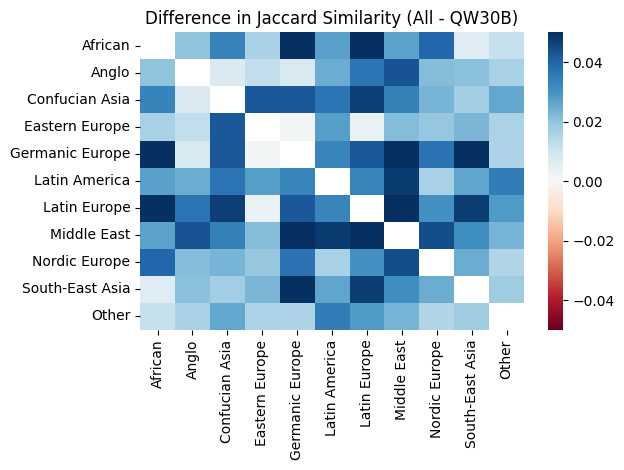

In [109]:
difference_matrix = all_jaccard_matrix - qw30b_jaccard_matrix
sns.heatmap(difference_matrix, annot=False, cmap="RdBu", center=0, vmin=-0.05, vmax=0.05)
plt.title("Difference in Jaccard Similarity (All - QW30B)")
plt.tight_layout()
plt.savefig('outputs/jaccard/qw30b_difference_jaccard_similarity.png')

## Difference of models with llava

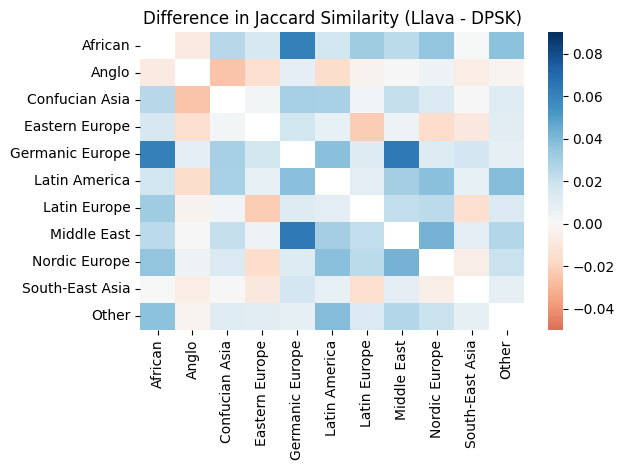

In [124]:
difference_matrix = llva_jaccard_matrix - dpsk_jaccard_matrix
sns.heatmap(difference_matrix, annot=False, cmap="RdBu", center=0, vmin=-0.05, vmax=0.09)
plt.title("Difference in Jaccard Similarity (Llava - DPSK)")
plt.tight_layout()
plt.savefig('outputs/jaccard/llava_dpsk_difference_jaccard_similarity.png')

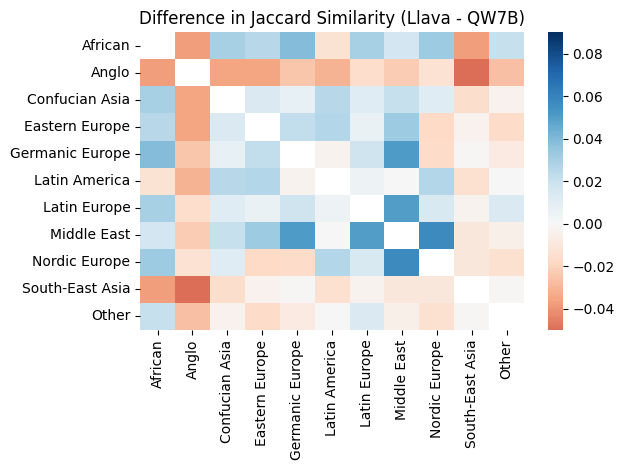

In [125]:
difference_matrix = llva_jaccard_matrix - qw7b_jaccard_matrix
sns.heatmap(difference_matrix, annot=False, cmap="RdBu", center=0, vmin=-0.05, vmax=0.09)
plt.title("Difference in Jaccard Similarity (Llava - QW7B)")
plt.tight_layout()
plt.savefig('outputs/jaccard/llava_qw7b_difference_jaccard_similarity.png')

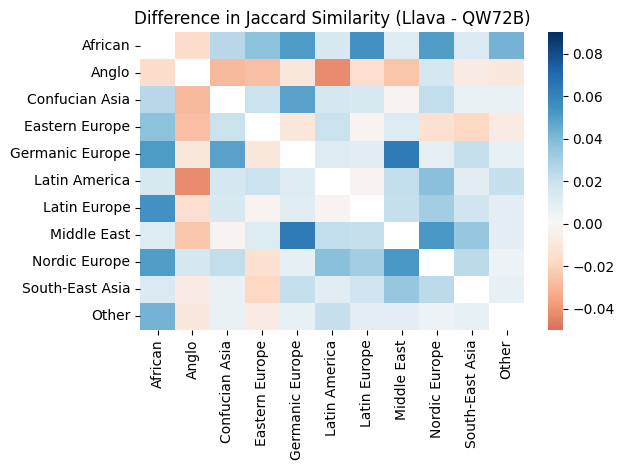

In [126]:
difference_matrix = llva_jaccard_matrix - qw72b_jaccard_matrix
sns.heatmap(difference_matrix, annot=False, cmap="RdBu", center=0, vmin=-0.05, vmax=0.09)
plt.title("Difference in Jaccard Similarity (Llava - QW72B)")
plt.tight_layout()
plt.savefig('outputs/jaccard/llava_qw72b_difference_jaccard_similarity.png')

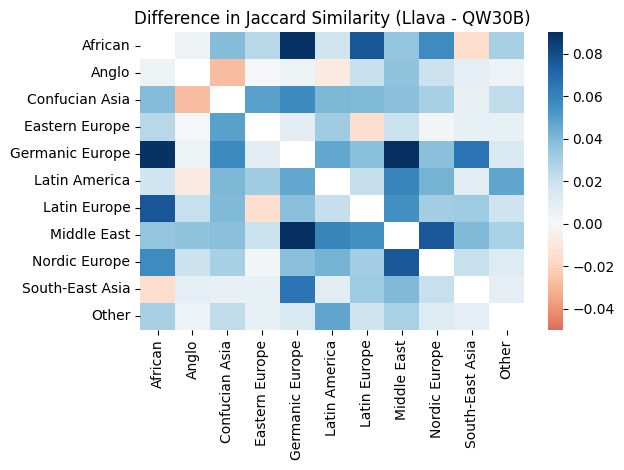

In [127]:
difference_matrix = llva_jaccard_matrix - qw30b_jaccard_matrix
sns.heatmap(difference_matrix, annot=False, cmap="RdBu", center=0, vmin=-0.05, vmax=0.09)
plt.title("Difference in Jaccard Similarity (Llava - QW30B)")
plt.tight_layout()
plt.savefig('outputs/jaccard/llava_qw30b_difference_jaccard_similarity.png')

## Frequency-region analysis for each model

In [2]:
def clean_activities(activity_list):
    res = []
    # filter empty strings and strings with non-english characters
    for term in activity_list:
        if term and not any('\u4e00' <= char <= '\u9fff' for char in term):
            res.append(term)
    return res


def apply_cannonical_map(activity_list, canonical_map):
    return [canonical_map.get(activity, activity) for activity in activity_list]

In [3]:
data = pd.read_pickle('/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/results_activity/indVLM_activity_vocab_deduplication_results.pkl')
deduped_vocabs,global_duplicates,canonical_map,labels = data['deduped_vocabularies'], data['global_duplicates'], data['canonical_map'], data['labels']

NUM_REGIONS = 11

dpsk_vocab = {l.split("_")[0]:v for l,v in zip(labels[:NUM_REGIONS], deduped_vocabs[:NUM_REGIONS])}
llva_vocab = {l.split("_")[0]:v for l,v in zip(labels[NUM_REGIONS:2*NUM_REGIONS], deduped_vocabs[NUM_REGIONS:2*NUM_REGIONS])}
qw7b_vocab = {l.split("_")[0]:v for l,v in zip(labels[2*NUM_REGIONS:3*NUM_REGIONS], deduped_vocabs[2*NUM_REGIONS:3*NUM_REGIONS])}
qw72b_vocab = {l.split("_")[0]:v for l,v in zip(labels[3*NUM_REGIONS:4*NUM_REGIONS], deduped_vocabs[3*NUM_REGIONS:4*NUM_REGIONS])}
qw30b_vocab = {l.split("_")[0]:v for l,v in zip(labels[4*NUM_REGIONS:], deduped_vocabs[4*NUM_REGIONS:])}

In [4]:
dpsk_df = pd.read_pickle('/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/cvpr_results/cultural_deepseek-vl2_final.pkl')
llva_df = pd.read_pickle('/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/cvpr_results/cultural_llava-v1.6-mistral-7b-hf_final.pkl')
qw7b_df = pd.read_pickle('/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/cvpr_results/cultural_Qwen2.5-VL-7B-Instruct_final.pkl')
qw72b_df = pd.read_pickle('/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/cvpr_results/cultural_Qwen2.5-VL-72B-Instruct_final.pkl')
qw30b_df = pd.read_pickle('/lustre/nvwulf/projects/CascanteBonillaGroup-nvwulf/pchitale/data/eccv/cvpr_results/cultural_Qwen3-VL-30B-A3B-Instruct_final.pkl')


dpsk_df['activities'] = dpsk_df['activities'].apply(clean_activities)
llva_df['activities'] = llva_df['activities'].apply(clean_activities)
qw7b_df['activities'] = qw7b_df['activities'].apply(clean_activities)
qw72b_df['activities'] = qw72b_df['activities'].apply(clean_activities)
qw30b_df['activities'] = qw30b_df['activities'].apply(clean_activities)


merged_df = pd.DataFrame(dpsk_df['file'])

merged_df = merged_df.merge(dpsk_df[['file', 'activities']], on='file', how='inner', suffixes=('', '_dpsk')).rename(columns={'activities': 'activities_dpsk'})
merged_df = merged_df.merge(llva_df[['file', 'activities']], on='file', how='inner', suffixes=('', '_llva')).rename(columns={'activities': 'activities_llva'})
merged_df = merged_df.merge(qw7b_df[['file', 'activities']], on='file', how='inner', suffixes=('', '_qw7b')).rename(columns={'activities': 'activities_qw7b'})
merged_df = merged_df.merge(qw72b_df[['file', 'activities']], on='file', how='inner', suffixes=('', '_qw72b')).rename(columns={'activities': 'activities_qw72b'})
merged_df = merged_df.merge(qw30b_df[['file', 'activities']], on='file', how='inner', suffixes=('', '_qw30b')).rename(columns={'activities': 'activities_qw30b'})

merged_df = merged_df.merge(dpsk_df[['file','globe_region','country']], on='file', how='inner')

region_wise_df = merged_df.groupby('globe_region').agg({'activities_dpsk': list, 'activities_llva': list, 'activities_qw7b': list, 'activities_qw72b': list, 'activities_qw30b': list}).reset_index()

region_wise_df['activities_dpsk'] = region_wise_df['activities_dpsk'].apply(lambda x: [item for sublist in x for item in sublist])
region_wise_df['activities_llva'] = region_wise_df['activities_llva'].apply(lambda x: [item for sublist in x for item in sublist])
region_wise_df['activities_qw7b'] = region_wise_df['activities_qw7b'].apply(lambda x: [item for sublist in x for item in sublist])
region_wise_df['activities_qw72b'] = region_wise_df['activities_qw72b'].apply(lambda x: [item for sublist in x for item in sublist])
region_wise_df['activities_qw30b'] = region_wise_df['activities_qw30b'].apply(lambda x: [item for sublist in x for item in sublist])

In [5]:
region_wise_df['activities_dpsk'] = region_wise_df['activities_dpsk'].apply(lambda x: apply_cannonical_map(x, canonical_map))
region_wise_df['activities_llva'] = region_wise_df['activities_llva'].apply(lambda x: apply_cannonical_map(x, canonical_map))
region_wise_df['activities_qw7b'] = region_wise_df['activities_qw7b'].apply(lambda x: apply_cannonical_map(x, canonical_map))
region_wise_df['activities_qw72b'] = region_wise_df['activities_qw72b'].apply(lambda x: apply_cannonical_map(x, canonical_map))
region_wise_df['activities_qw30b'] = region_wise_df['activities_qw30b'].apply(lambda x: apply_cannonical_map(x, canonical_map))

In [6]:
region_wise_df.head()

,globe_region,activities_dpsk,activities_llva,activities_qw7b,activities_qw72b,activities_qw30b
0,African,"[socialize, holding items, socialize, wait, ta...","[socialize, socialize, wait, pass by, walk, so...","[stand, walk, carrying bags, holding children,...","[walk, carrying a child, walk, walk, walk, wal...","[walk, stand, interact, carrying a child, walk..."
1,Anglo,"[socialize, conversing, waiting for transport,...","[walk, socialize, talk, phone, arrival, social...","[walk, looking at shop, walk, walk, walk, walk...","[walk, window shopping, walk, walk, commute, s...","[walk, walk, displaying posters, walk, stand, ..."
2,Confucian Asia,"[walk, umbrella, rain, walk, rainy walk, walk,...","[night out, walk, socialize, commute, walk, so...","[walk, holding umbrellas, walk, crossing road,...","[rainy walk, wait, socialize, unknown, wait, w...","[walk, walk, holding umbrellas, walk, walk, ho..."
3,Eastern Europe,"[stand, walk, socialize, talk, socialize, line...","[sightseeing, unknown, walk, talk, socialize, ...","[stand, wait, socialize, stand, observe, obser...","[walk, talk, sightseeing, socialize, wait, obs...","[sightseeing, socialize, stand, sightseeing, w..."
4,Germanic Europe,"[observe surroundings, wait, socialize, standi...","[socialize, statue, prayer, explore, socialize...","[wait, walk, walk, eat, drink, socialize, wal...","[statue display, walk, walk, sunbathe, relax, ...","[walk, walk, sit, relax, socialize, walk, walk..."


In [7]:
# use counter to track counts of activities in each region for each model

region_wise_df['activity_counts_dpsk'] = region_wise_df['activities_dpsk'].apply(lambda x: Counter(x))
region_wise_df['activity_counts_llva'] = region_wise_df['activities_llva'].apply(lambda x: Counter(x))
region_wise_df['activity_counts_qw7b'] = region_wise_df['activities_qw7b'].apply(lambda x: Counter(x))
region_wise_df['activity_counts_qw72b'] = region_wise_df['activities_qw72b'].apply(lambda x: Counter(x))
region_wise_df['activity_counts_qw30b'] = region_wise_df['activities_qw30b'].apply(lambda x: Counter(x))

region_wise_df.iloc[[-2, -1]] = region_wise_df.iloc[[-1, -2]].values

In [8]:
# verifying all activities in the vocab are present in the region-wise counts

for r in region_wise_df['globe_region'].values:
    s = set()
    for w in dpsk_vocab[r]:
        s.add(w)
    if s != dpsk_vocab[r]:
        print(f"Mismatch in {r} for dpsk_vocab")
    
    s = set()
    for w in llva_vocab[r]:
        s.add(w)
    if s != llva_vocab[r]:
        print(f"Mismatch in {r} for llva_vocab")

    s = set()
    for w in qw7b_vocab[r]:
        s.add(w)
    if s != qw7b_vocab[r]:
        print(f"Mismatch in {r} for qw7b_vocab")

    s = set()
    for w in qw72b_vocab[r]:
        s.add(w)
    if s != qw72b_vocab[r]:
        print(f"Mismatch in {r} for qw72b_vocab")

    s = set()
    for w in qw30b_vocab[r]:
        s.add(w)
    if s != qw30b_vocab[r]:
        print(f"Mismatch in {r} for qw30b_vocab")

In [9]:
vocab = list(set().union(*deduped_vocabs))

In [10]:
model = SentenceTransformer("Qwen/Qwen3-Embedding-8B", device="cpu") 

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [11]:
# 2. Generate Embeddings using Qwen3-8B
# Note: Ensure you have sufficient VRAM for an 8B model
embeddings = model.encode(vocab, show_progress_bar=True)

Batches:   0%|          | 0/235 [00:00<?, ?it/s]

In [15]:
# save embeddings to a pickle file
import pickle
with open('outputs/vocab_embeddings_qwen3_8b.pkl', 'wb') as f:
    pickle.dump({'vocab': vocab, 'embeddings': embeddings}, f)

In [12]:
# 3. Dimensionality Reduction
reducer = umap.UMAP(n_components=2, metric='cosine', random_state=42)
umap_coords = reducer.fit_transform(embeddings)

/lustre/nvwulf/home/pchitale/miniconda3/envs/vpy310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
# Map activity string -> (x, y)
coord_map = {act: umap_coords[i] for i, act in enumerate(vocab)}

In [14]:
model_names = {'dpsk': 'Deepseek-VL2', 'llva': 'Llava-v1.6-mistral-7b-hf', 'qw7b': 'Qwen2.5-VL-7B-Instruct', 'qw72b': 'Qwen2.5-VL-72B-Instruct', 'qw30b': 'Qwen3-VL-30B-A3B-Instruct'}

In [99]:
def get_activity_plot(region_wise_df, counter_col, region_col):

    global model_names, coord_map
    MIN_FREQ = 10 # Minimum frequency to plot an activity
    LABELS_PER_REGION = 5

    # 4. Flatten the DataFrame for Plotting
    # We need one row per (region, activity) pair
    plot_rows = []
    for _, row in region_wise_df.iterrows():
        region = row[region_col]
        counts = row[counter_col] # This is the Counter object
        
        for activity, freq in counts.items():
            if freq > MIN_FREQ:
                x, y = coord_map[activity]
                plot_rows.append({
                    "Region": region,
                    "Activity": activity,
                    "Count": freq,
                    "UMAP_1": x,
                    "UMAP_2": y
                })
            
    plot_df = pd.DataFrame(plot_rows)


    # # 4.1. Identify how many regions each activity appears in
    # activity_region_counts = plot_df.groupby('Activity')['Region'].nunique()

    # # 4.2. Filter for activities that appear in ONLY one region
    # unique_activities = activity_region_counts[activity_region_counts == 1].index
    # unique_df = plot_df[plot_df['Activity'].isin(unique_activities)].copy()

    # # 4.3. For each region, get the top N most frequent "unique" activities
    # top_unique_labels = (
    #     unique_df.sort_values(['Region', 'Count'], ascending=[True, False])
    #     .groupby('Region')
    #     .head(LABELS_PER_REGION)
    # )

    # # Create a mapping for the label column
    # # We use a set of tuples (Region, Activity) to ensure we label the right dot
    # label_keys = set(zip(top_unique_labels['Region'], top_unique_labels['Activity']))
    # plot_df['Label'] = plot_df.apply(
    #     lambda x: x['Activity'] if (x['Region'], x['Activity']) in label_keys else "", 
    #     axis=1
    # )

    # 5. Interactive Bubble Plot
    fig = px.scatter(
        plot_df, 
        x="UMAP_1", 
        y="UMAP_2",
        size="Count", 
        color="Region",
        # text="Label",
        hover_name="Activity",
        hover_data=["Count"],
        title=f"{model_names[counter_col.split('_')[-1]]} Region-wise Activity Semantic Map", # UPDATE THIS WHEN CHANGING MODEL
        template="plotly_white",
        size_max=70, # Adjust bubble scaling
        opacity=0.7,
        color_discrete_sequence=['black', 'gray', 'aqua', 'red', 'blue', 'green', 'yellow', 'orange', 'brown', 'purple', 'pink']
    )

    fig.update_traces(
        textposition='bottom center',  # Moves label to the diagonal
        textfont=dict(size=12, color="white"),
        cliponaxis=False, # Prevents labels at the edge of the plot from being cut off,
    )

    fig.update_layout(
        legend_title_text='World Regions',
        xaxis_title="Dim 1",
        yaxis_title="Dim 2",
        width=800,
        height=800,
        # uirevision='constant_map_frame',
        xaxis=dict(
            range=[0,10],
            autorange=False,  # This is critical to prevent Plotly from over-riding you
            showgrid=True,
            zeroline=True,
            constrain='domain'
        ),
        yaxis=dict(
            range=[2,12],
            autorange=False,
            scaleanchor="x",  # Keeps the 1:1 pixel ratio
            scaleratio=1,
            showgrid=True,
            zeroline=True
        ),
        title={
            'xanchor': 'center',
            'x': 0.5
        },
        margin=dict(l=60, r=60, t=60, b=60),
    )

    fig.show()

    # fig.write_html(f"{counter_col.split('_')[-1]}_region_activity_map.html", include_plotlyjs='cdn') # Smaller file, needs internet
    fig.write_image(f"outputs/clusters/{counter_col.split('_')[-1]}_region_activity_map.pdf")

In [101]:
region_col = 'globe_region'
counter_col = 'activity_counts_qw30b' # You can choose which model's counts

for counter_col in ['activity_counts_dpsk', 'activity_counts_llva', 'activity_counts_qw7b', 'activity_counts_qw72b', 'activity_counts_qw30b']:
    get_activity_plot(region_wise_df, counter_col, region_col)
    # break